In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '../scripts'))
from utils.load_env import PATH_DATA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import polars as pl 

pl.enable_string_cache() # Enable string cache to handle categorical comparisons

pd.set_option('display.max_columns', None)

def show_df(df, polar=True):
    print(df.shape)
    if polar:
        display(pd.concat([df.head(2).to_pandas(), df.tail(1).to_pandas()]))
    else:
        display(pd.concat([df.head(2), df.tail(1)]))

## Chargement des données gold

In [2]:
oct_jan = pl.read_parquet(f"{PATH_DATA}/gold/2019-Oct_2020-Jan_features.parquet")
show_df(oct_jan, polar=True)

(1602686, 16)


,user_id,total_purchases,total_spend,median_order_value,price_sensitivity_score,purchase_frequency_per_day,price_range,premium_product_affinity,budget_product_affinity,discount_affinity,avg_discount_pct,median_inter_session_gap_hours,inter_session_gap_variance,session_transitions,same_day_return_rate,weekly_return_rate
0,517674850,0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0,0.000000,0.000000
1,520175934,3,407.750000,126.820000,15.825224,1.5,27.450005,0.0,0.0,0.666667,1.873431,65.0,232.007902,4,0.500000,0.250000
0,529889986,1,37.439999,37.439999,0.000000,1.0,0.000000,0.0,1.0,1.000000,0.133367,95.5,132.798389,14,0.142857,0.285714


## Clustering

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from kneed import KneeLocator

def clustering(
    features: pl.DataFrame, 
    show_plot: bool = False, 
    method: str = "kneed"  # or "davies_bouldin"
) -> int:
    assert method in {"davies_bouldin", "kneed"}, "Method must be 'davies_bouldin' or 'kneed'"

    # Prepare the data
    feature_data = features.drop("user_id").to_numpy()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(feature_data)

    sse = []
    db_scores = []
    K_range = range(2, 21)
    labels_list = []

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(scaled_data)
        labels_list.append(labels)
        sse.append(kmeans.inertia_)
        if method == "davies_bouldin":
            score = davies_bouldin_score(scaled_data, labels)
            db_scores.append(score)

    if method == "davies_bouldin":
        optimal_k = K_range[db_scores.index(min(db_scores))]
    else:  # method == "kneed"
        knee = KneeLocator(K_range, sse, curve='convex', direction='decreasing')
        optimal_k = knee.knee or K_range[0]  # fallback if no knee found

    if show_plot:
        plt.figure(figsize=(10, 6))
        plt.plot(K_range, sse, marker='o', label='SSE')
        if method == "davies_bouldin":
            plt.plot(K_range, db_scores, marker='x', label='Davies-Bouldin Index')
        plt.xlabel('Number of Clusters (K)')
        plt.xticks(K_range)
        plt.ylabel('Score')
        plt.title(f'Optimal K ({method})')
        plt.axvline(optimal_k, color='r', linestyle='--', label=f'Optimal K: {optimal_k}')
        plt.legend()
        plt.show()
    
    # add cluster labels to the features DataFrame
    res = features.with_columns(
        pl.Series("cluster", labels_list[K_range.index(optimal_k)])
    )
    return res


In [4]:
transactional_features = oct_jan.select([
    "user_id",
    "total_purchases", # Number of purchase events
    "total_spend", # Sum of all purchase amounts
    "median_order_value", # Median purchase amount
    "price_sensitivity_score", # Standard deviation of purchase prices
    # "purchase_frequency_per_day", # Purchases per active day
    "price_range", # Range of purchase prices
])

price_affinity_features = oct_jan.select([
    "user_id",
    "premium_product_affinity", # % of purchases in top 10% price range
    "budget_product_affinity", # % of purchases in bottom 25% price range
    "discount_affinity", # % of purchases below normal product price
    "avg_discount_pct" # Average discount received on discounted purchases
])

inter_session_return_features = oct_jan.select([
    "user_id",
    "median_inter_session_gap_hours", # Median hours between sessions
    "inter_session_gap_variance", # Standard deviation of session gaps
    "session_transitions", # Number of session-to-session transitions
    "same_day_return_rate", # % of returns within 24 hours
    "weekly_return_rate" # % of returns after 1 week
])

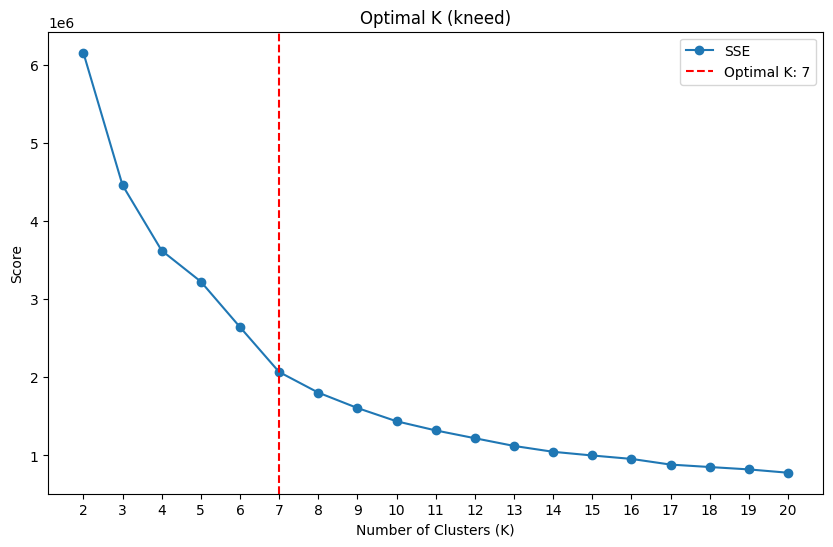

In [5]:
inter_session_return_features_pred = clustering(inter_session_return_features, show_plot=True)

In [6]:
grouped = inter_session_return_features_pred.to_pandas().groupby('cluster')

# Calculate descriptive statistics for each cluster
for cluster, group in grouped:
    print(f"\nCluster {cluster} - Behavioral Characteristics:")

    unique_users = group['user_id'].nunique()
    median_gap = group['median_inter_session_gap_hours'].mean()
    gap_variance = group['inter_session_gap_variance'].mean()
    transitions = group['session_transitions'].mean()
    same_day_return = group['same_day_return_rate'].mean()
    weekly_return = group['weekly_return_rate'].mean()

    print(f"Number of users in the cluster: {unique_users}")
    print(f"Avg. median inter-session gap (hours): {median_gap:.2f}")
    print(f"Avg. session gap variance: {gap_variance:.2f}")
    print(f"Avg. session transitions: {transitions:.2f}")
    print(f"Avg. same-day return rate: {same_day_return:.2%}")
    print(f"Avg. weekly return rate: {weekly_return:.2%}")   


Cluster 0 - Behavioral Characteristics:
Number of users in the cluster: 574484
Avg. median inter-session gap (hours): 82.39
Avg. session gap variance: 221.89
Avg. session transitions: 11.56
Avg. same-day return rate: 30.82%
Avg. weekly return rate: 29.89%

Cluster 1 - Behavioral Characteristics:
Number of users in the cluster: 110402
Avg. median inter-session gap (hours): 27.73
Avg. session gap variance: 84.13
Avg. session transitions: 44.26
Avg. same-day return rate: 49.61%
Avg. weekly return rate: 8.46%

Cluster 2 - Behavioral Characteristics:
Number of users in the cluster: 41870
Avg. median inter-session gap (hours): 1353.19
Avg. session gap variance: 40.76
Avg. session transitions: 1.15
Avg. same-day return rate: 0.00%
Avg. weekly return rate: 100.00%

Cluster 3 - Behavioral Characteristics:
Number of users in the cluster: 248252
Avg. median inter-session gap (hours): 349.15
Avg. session gap variance: 195.90
Avg. session transitions: 3.67
Avg. same-day return rate: 4.28%
Avg. wee

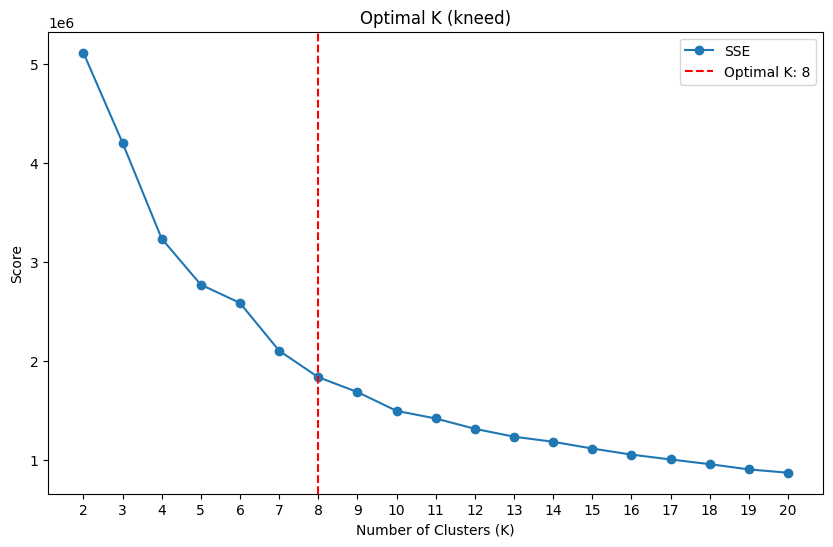

In [7]:
transactional_features_pred = clustering(transactional_features, show_plot=True)

In [8]:
grouped = transactional_features_pred.to_pandas().groupby('cluster')

for cluster, group in grouped:
    print(f"\nCluster {cluster} – Purchase Behavior Summary:")

    unique_users = group['user_id'].nunique()
    total_purchases = group["total_purchases"].mean()
    total_spend = group["total_spend"].mean()
    median_order_value = group["median_order_value"].mean()
    price_sensitivity = group["price_sensitivity_score"].mean()
    price_range = group["price_range"].mean()

    print(f"Number of users in the cluster: {unique_users}")
    print(f"Avg. total purchases: {total_purchases:.2f}")
    print(f"Avg. total spend: ${total_spend:.2f}")
    print(f"Median order value: ${median_order_value:.2f}")
    print(f"Price sensitivity score (std dev): {price_sensitivity:.2f}")
    print(f"Avg. price range: {price_range:.2f}")


Cluster 0 – Purchase Behavior Summary:
Number of users in the cluster: 440185
Avg. total purchases: 2.37
Avg. total spend: $519.20
Median order value: $267.58
Price sensitivity score (std dev): 27.93
Avg. price range: 51.55

Cluster 1 – Purchase Behavior Summary:
Number of users in the cluster: 51274
Avg. total purchases: 5.27
Avg. total spend: $3351.74
Median order value: $628.23
Price sensitivity score (std dev): 556.35
Avg. price range: 1114.47

Cluster 2 – Purchase Behavior Summary:
Number of users in the cluster: 865218
Avg. total purchases: 0.88
Avg. total spend: $71.30
Median order value: $52.59
Price sensitivity score (std dev): 3.12
Avg. price range: 5.24

Cluster 3 – Purchase Behavior Summary:
Number of users in the cluster: 12864
Avg. total purchases: 35.84
Avg. total spend: $14046.68
Median order value: $447.61
Price sensitivity score (std dev): 247.96
Avg. price range: 923.96

Cluster 4 – Purchase Behavior Summary:
Number of users in the cluster: 100927
Avg. total purchas

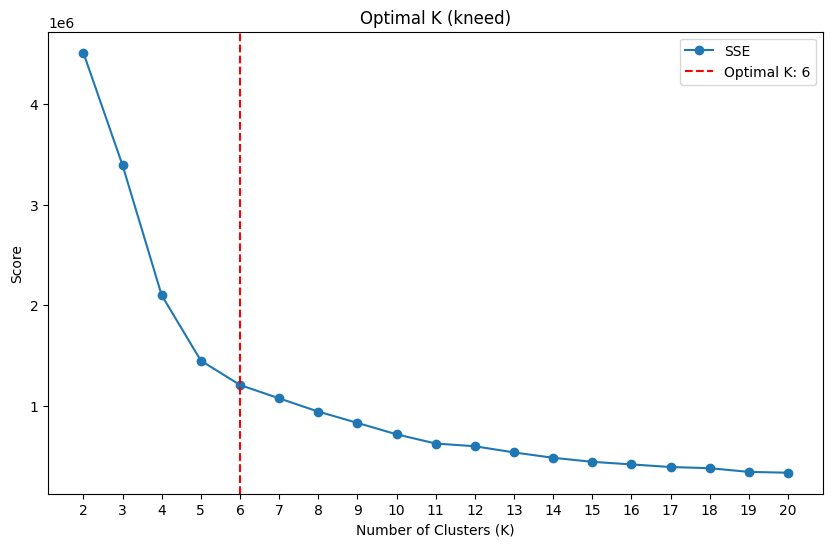

In [9]:
price_affinity_features_pred = clustering(price_affinity_features, show_plot=True)

In [10]:
grouped = price_affinity_features_pred.to_pandas().groupby('cluster')

# Calculate descriptive statistics for each cluster
for cluster, group in grouped:
    print(f"\nCluster {cluster} - Price Affinity Characteristics:")

    unique_users = group['user_id'].nunique()
    premium_affinity = group['premium_product_affinity'].mean()
    budget_affinity = group['budget_product_affinity'].mean()
    discount_affinity = group['discount_affinity'].mean()
    avg_discount_pct = group['avg_discount_pct'].mean()

    print(f"Number of users in the cluster: {unique_users}")
    print(f"Avg. premium product affinity: {premium_affinity:.2%}")
    print(f"Avg. budget product affinity: {budget_affinity:.2%}")
    print(f"Avg. discount affinity: {discount_affinity:.2%}")
    print(f"Avg. discount percentage: {avg_discount_pct:.2f}%")


Cluster 0 - Price Affinity Characteristics:
Number of users in the cluster: 299722
Avg. premium product affinity: 1.81%
Avg. budget product affinity: 1.85%
Avg. discount affinity: 85.59%
Avg. discount percentage: 3.21%

Cluster 1 - Price Affinity Characteristics:
Number of users in the cluster: 238336
Avg. premium product affinity: 0.22%
Avg. budget product affinity: 90.91%
Avg. discount affinity: 2.03%
Avg. discount percentage: 0.08%

Cluster 2 - Price Affinity Characteristics:
Number of users in the cluster: 800277
Avg. premium product affinity: 0.58%
Avg. budget product affinity: 1.50%
Avg. discount affinity: 2.62%
Avg. discount percentage: 0.15%

Cluster 3 - Price Affinity Characteristics:
Number of users in the cluster: 108026
Avg. premium product affinity: 86.67%
Avg. budget product affinity: 2.37%
Avg. discount affinity: 38.79%
Avg. discount percentage: 1.76%

Cluster 4 - Price Affinity Characteristics:
Number of users in the cluster: 45067
Avg. premium product affinity: 2.08%


In [12]:
# ============================================================================
# ANALYSE DE LA QUALITÉ ET STABILITÉ DES SEGMENTS
# ============================================================================

print("="*80)
print("ÉVALUATION DE LA QUALITÉ ET STABILITÉ DES SEGMENTS")
print("="*80)

# Charger toutes les fenêtres temporelles
time_windows = [
    "2019-Oct_2020-Jan",
    "2019-Nov_2020-Feb", 
    "2019-Dec_2020-Mar",
    "2020-Jan_2020-Apr"
]

datasets = {}
for window in time_windows:
    try:
        path = f"{PATH_DATA}/gold/{window}_features.parquet"
        datasets[window] = pl.read_parquet(path)
        print(f"✅ {window}: {datasets[window].shape[0]:,} users, {datasets[window].shape[1]} features")
    except Exception as e:
        print(f"❌ {window}: Error - {e}")

print(f"\nNombre total de fenêtres chargées: {len(datasets)}")

ÉVALUATION DE LA QUALITÉ ET STABILITÉ DES SEGMENTS
✅ 2019-Oct_2020-Jan: 1,602,686 users, 16 features
✅ 2019-Nov_2020-Feb: 1,657,929 users, 16 features
✅ 2019-Dec_2020-Mar: 1,660,520 users, 16 features
✅ 2020-Jan_2020-Apr: 1,655,865 users, 16 features

Nombre total de fenêtres chargées: 4


## Évaluation de la qualité du clustering

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Interprétation des métriques

• Silhouette Score (0 à 1): Mesure la cohésion intra-cluster vs séparation inter-cluster
  - \> 0.5: Excellent clustering
  - 0.3-0.5: Bon clustering
  - < 0.3: Clustering faible

• Davies-Bouldin Score (0+): Mesure la similarité moyenne entre clusters
  - Plus proche de 0 = meilleur
  - < 1.0: Très bon clustering
  - 1.0-2.0: Bon clustering

• Calinski-Harabasz Score (0+): Ratio variance inter/intra-cluster
  - Plus élevé = meilleur
  - Pas de seuil absolu, à comparer relativement

In [17]:
def evaluate_clustering_quality(features_df, cluster_labels, sample_size=50000):
    """
    Évalue la qualité du clustering avec plusieurs métriques
    
    Args:
        features_df: DataFrame polars avec les features (sans user_id)
        cluster_labels: Array avec les labels des clusters
        sample_size: Taille de l'échantillon pour le silhouette score (défaut: 50000)
    
    Returns:
        dict: Dictionnaire avec les métriques de qualité
    """
    # Préparer les données
    feature_data = features_df.to_numpy()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(feature_data)
    
    # Calculer les métriques
    metrics = {}
    
    # Silhouette score sur échantillon stratifié pour éviter les problèmes de mémoire
    try:
        if len(cluster_labels) > sample_size:
            print(f"    ⚠️  Échantillonnage stratifié pour Silhouette Score ({sample_size:,} échantillons)")
            
            # Échantillonnage stratifié par cluster
            unique_clusters = np.unique(cluster_labels)
            sample_indices = []
            
            for cluster in unique_clusters:
                cluster_indices = np.where(cluster_labels == cluster)[0]
                cluster_sample_size = min(len(cluster_indices), sample_size // len(unique_clusters))
                if cluster_sample_size > 0:
                    sampled_indices = np.random.choice(cluster_indices, cluster_sample_size, replace=False)
                    sample_indices.extend(sampled_indices)
            
            sample_indices = np.array(sample_indices)
            np.random.shuffle(sample_indices)
            
            metrics['silhouette_score'] = silhouette_score(
                scaled_data[sample_indices], 
                cluster_labels[sample_indices]
            )
            metrics['silhouette_sample_size'] = len(sample_indices)
        else:
            metrics['silhouette_score'] = silhouette_score(scaled_data, cluster_labels)
            metrics['silhouette_sample_size'] = len(cluster_labels)
    except Exception as e:
        print(f"    ❌ Erreur Silhouette Score: {e}")
        metrics['silhouette_score'] = None
        metrics['silhouette_sample_size'] = 0
        
    try:
        metrics['calinski_harabasz_score'] = calinski_harabasz_score(scaled_data, cluster_labels)
    except Exception as e:
        print(f"    ❌ Erreur Calinski-Harabasz: {e}")
        metrics['calinski_harabasz_score'] = None
        
    try:
        metrics['davies_bouldin_score'] = davies_bouldin_score(scaled_data, cluster_labels)
    except Exception as e:
        print(f"    ❌ Erreur Davies-Bouldin: {e}")
        metrics['davies_bouldin_score'] = None
    
    metrics['n_clusters'] = len(np.unique(cluster_labels))
    metrics['n_samples'] = len(cluster_labels)
    
    return metrics

def print_quality_metrics(metrics, title="Métriques de qualité"):
    """Affiche les métriques de qualité de manière formatée"""
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Nombre de clusters: {metrics['n_clusters']}")
    print(f"Nombre d'échantillons: {metrics['n_samples']:,}")
    
    if metrics['silhouette_score'] is not None:
        sample_info = ""
        if 'silhouette_sample_size' in metrics and metrics['silhouette_sample_size'] < metrics['n_samples']:
            sample_info = f" (échantillon: {metrics['silhouette_sample_size']:,})"
        print(f"Silhouette Score: {metrics['silhouette_score']:.4f}{sample_info}")
        print("  → Plus proche de 1 = meilleur (cohésion intra-cluster et séparation inter-cluster)")
    
    if metrics['calinski_harabasz_score'] is not None:
        print(f"Calinski-Harabasz Score: {metrics['calinski_harabasz_score']:.2f}")
        print("  → Plus élevé = meilleur (ratio variance inter/intra-cluster)")
    
    if metrics['davies_bouldin_score'] is not None:
        print(f"Davies-Bouldin Score: {metrics['davies_bouldin_score']:.4f}")
        print("  → Plus proche de 0 = meilleur (similarité moyenne cluster/cluster le plus proche)")

In [18]:
# ============================================================================
# 1. ÉVALUATION DE LA QUALITÉ DES CLUSTERINGS (OCTOBRE-JANVIER)
# ============================================================================

print("\n" + "="*60)
print("1. ÉVALUATION DE LA QUALITÉ DES CLUSTERINGS")
print("="*60)

# Évaluer chaque catégorie de features
categories = {
    'inter_session': (inter_session_return_features, inter_session_return_features_pred),
    'transactional': (transactional_features, transactional_features_pred),
    'price_affinity': (price_affinity_features, price_affinity_features_pred)
}

quality_results = {}

for category, (features, predicted) in categories.items():
    print(f"\n📊 Catégorie: {category.upper()}")
    
    # Extraire les features sans user_id
    feature_cols = [col for col in features.columns if col != 'user_id']
    features_only = features.select(feature_cols)
    
    # Extraire les labels de cluster
    cluster_labels = predicted.select('cluster').to_numpy().flatten()
    
    # Évaluer la qualité
    metrics = evaluate_clustering_quality(features_only, cluster_labels)
    quality_results[category] = metrics
    
    print_quality_metrics(metrics, f"Métriques pour {category}")
    
    # Afficher la distribution des clusters
    cluster_counts = predicted.group_by('cluster').agg(pl.len().alias('count')).sort('cluster')
    print(f"\nDistribution des clusters:")
    for row in cluster_counts.iter_rows():
        cluster_id, count = row
        percentage = (count / predicted.shape[0]) * 100
        print(f"  Cluster {cluster_id}: {count:,} users ({percentage:.1f}%)")


1. ÉVALUATION DE LA QUALITÉ DES CLUSTERINGS

📊 Catégorie: INTER_SESSION
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)

Métriques pour inter_session
----------------------------
Nombre de clusters: 7
Nombre d'échantillons: 1,602,686
Silhouette Score: 0.4062 (échantillon: 49,994)
  → Plus proche de 1 = meilleur (cohésion intra-cluster et séparation inter-cluster)
Calinski-Harabasz Score: 767529.17
  → Plus élevé = meilleur (ratio variance inter/intra-cluster)
Davies-Bouldin Score: 0.8679
  → Plus proche de 0 = meilleur (similarité moyenne cluster/cluster le plus proche)

Distribution des clusters:
  Cluster 0: 574,484 users (35.8%)
  Cluster 1: 110,402 users (6.9%)
  Cluster 2: 41,870 users (2.6%)
  Cluster 3: 248,252 users (15.5%)
  Cluster 4: 338,442 users (21.1%)
  Cluster 5: 183,424 users (11.4%)
  Cluster 6: 105,812 users (6.6%)

📊 Catégorie: TRANSACTIONAL
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)

Métriques pour i

In [19]:
# ============================================================================
# 2. ANALYSE DE STABILITÉ TEMPORELLE
# ============================================================================

def train_clustering_model(features_df, method="kneed"):
    """
    Entraîne un modèle de clustering et retourne le modèle et les métriques
    
    Args:
        features_df: DataFrame avec les features (sans user_id)
        method: Méthode pour déterminer le nombre optimal de clusters
    
    Returns:
        tuple: (modèle KMeans, scaler, nombre de clusters optimal, métriques)
    """
    # Préparer les données
    feature_data = features_df.to_numpy()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(feature_data)
    
    # Déterminer le nombre optimal de clusters (reprise de la fonction clustering existante)
    sse = []
    K_range = range(2, 21)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(scaled_data)
        sse.append(kmeans.inertia_)
    
    if method == "kneed":
        from kneed import KneeLocator
        knee = KneeLocator(K_range, sse, curve='convex', direction='decreasing')
        optimal_k = knee.knee or K_range[0]
    else:
        optimal_k = K_range[0]  # fallback
    
    # Entraîner le modèle final
    final_model = KMeans(n_clusters=optimal_k, random_state=42)
    cluster_labels = final_model.fit_predict(scaled_data)
    
    # Évaluer la qualité
    metrics = evaluate_clustering_quality(features_df, cluster_labels)
    
    return final_model, scaler, optimal_k, metrics

def apply_clustering_model(model, scaler, features_df):
    """
    Applique un modèle de clustering pré-entraîné à de nouvelles données
    
    Args:
        model: Modèle KMeans entraîné
        scaler: Scaler entraîné
        features_df: DataFrame avec les features (sans user_id)
    
    Returns:
        array: Labels des clusters
    """
    feature_data = features_df.to_numpy()
    scaled_data = scaler.transform(feature_data)
    cluster_labels = model.predict(scaled_data)
    return cluster_labels

In [20]:
print("\n" + "="*60)
print("2.A. STABILITÉ PAR RÉ-ENTRAÎNEMENT SUR CHAQUE PÉRIODE")
print("="*60)

# Analyser chaque catégorie de features sur toutes les fenêtres temporelles
feature_categories = {
    'inter_session': ['median_inter_session_gap_hours', 'inter_session_gap_variance', 
                     'session_transitions', 'same_day_return_rate', 'weekly_return_rate'],
    'transactional': ['total_purchases', 'total_spend', 'median_order_value', 
                     'price_sensitivity_score', 'price_range'],
    'price_affinity': ['premium_product_affinity', 'budget_product_affinity', 
                      'discount_affinity', 'avg_discount_pct']
}

temporal_stability_results = {}

for category, feature_cols in feature_categories.items():
    print(f"\n🔄 Catégorie: {category.upper()}")
    temporal_stability_results[category] = {}
    
    for window in time_windows:
        print(f"\n  📅 Période: {window}")
        
        # Extraire les features pour cette période
        features_df = datasets[window].select(['user_id'] + feature_cols)
        features_only = features_df.select(feature_cols)
        
        # Entraîner le modèle
        model, scaler, optimal_k, metrics = train_clustering_model(features_only)
        
        # Stocker les résultats
        temporal_stability_results[category][window] = {
            'model': model,
            'scaler': scaler,
            'optimal_k': optimal_k,
            'metrics': metrics,
            'features_df': features_df
        }
        
        print(f"    Clusters optimaux: {optimal_k}")
        print(f"    Silhouette Score: {metrics['silhouette_score']:.4f}" if metrics['silhouette_score'] else "    Silhouette Score: N/A")
        print(f"    Davies-Bouldin Score: {metrics['davies_bouldin_score']:.4f}" if metrics['davies_bouldin_score'] else "    Davies-Bouldin Score: N/A")


2.A. STABILITÉ PAR RÉ-ENTRAÎNEMENT SUR CHAQUE PÉRIODE

🔄 Catégorie: INTER_SESSION

  📅 Période: 2019-Oct_2020-Jan
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)
    Clusters optimaux: 7
    Silhouette Score: 0.4056
    Davies-Bouldin Score: 0.8679

  📅 Période: 2019-Nov_2020-Feb
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)
    Clusters optimaux: 8
    Silhouette Score: 0.4007
    Davies-Bouldin Score: 0.8899

  📅 Période: 2019-Dec_2020-Mar
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)
    Clusters optimaux: 7
    Silhouette Score: 0.4148
    Davies-Bouldin Score: 0.8589

  📅 Période: 2020-Jan_2020-Apr
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échantillons)
    Clusters optimaux: 7
    Silhouette Score: 0.4117
    Davies-Bouldin Score: 0.8621

🔄 Catégorie: TRANSACTIONAL

  📅 Période: 2019-Oct_2020-Jan
    ⚠️  Échantillonnage stratifié pour Silhouette Score (50,000 échan

In [21]:
# Analyser l'évolution des métriques dans le temps
print("\n" + "="*60)
print("2.B. ÉVOLUTION DES MÉTRIQUES DANS LE TEMPS")
print("="*60)

for category in feature_categories.keys():
    print(f"\n📈 {category.upper()}")
    print("-" * 40)
    
    # Créer un tableau récapitulatif
    results_table = []
    for window in time_windows:
        result = temporal_stability_results[category][window]
        metrics = result['metrics']
        
        row = {
            'période': window,
            'nb_clusters': result['optimal_k'],
            'nb_users': metrics['n_samples'],
            'silhouette': metrics['silhouette_score'],
            'davies_bouldin': metrics['davies_bouldin_score'],
            'calinski_harabasz': metrics['calinski_harabasz_score']
        }
        results_table.append(row)
    
    # Afficher le tableau
    print(f"{'Période':<20} {'Clusters':<10} {'Users':<12} {'Silhouette':<12} {'Davies-B':<10} {'Calinski-H':<12}")
    print("-" * 76)
    
    for row in results_table:
        silhouette_str = f"{row['silhouette']:.4f}" if row['silhouette'] else "N/A"
        davies_str = f"{row['davies_bouldin']:.4f}" if row['davies_bouldin'] else "N/A"
        calinski_str = f"{row['calinski_harabasz']:.0f}" if row['calinski_harabasz'] else "N/A"
        
        print(f"{row['période']:<20} {row['nb_clusters']:<10} {row['nb_users']:<12,} {silhouette_str:<12} {davies_str:<10} {calinski_str:<12}")
    
    # Analyser la stabilité du nombre de clusters
    cluster_counts = [row['nb_clusters'] for row in results_table]
    cluster_stability = len(set(cluster_counts)) == 1
    
    print(f"\n  📊 Stabilité du nombre de clusters: {'✅ STABLE' if cluster_stability else '❌ INSTABLE'}")
    if not cluster_stability:
        print(f"     Variation: {min(cluster_counts)} à {max(cluster_counts)} clusters")
    
    # Analyser la tendance des métriques
    silhouette_scores = [row['silhouette'] for row in results_table if row['silhouette'] is not None]
    if len(silhouette_scores) > 1:
        silhouette_trend = "📈 Amélioration" if silhouette_scores[-1] > silhouette_scores[0] else "📉 Dégradation"
        print(f"  📈 Tendance Silhouette Score: {silhouette_trend} ({silhouette_scores[0]:.4f} → {silhouette_scores[-1]:.4f})")


2.B. ÉVOLUTION DES MÉTRIQUES DANS LE TEMPS

📈 INTER_SESSION
----------------------------------------
Période              Clusters   Users        Silhouette   Davies-B   Calinski-H  
----------------------------------------------------------------------------
2019-Oct_2020-Jan    7          1,602,686    0.4056       0.8679     767529      
2019-Nov_2020-Feb    8          1,657,929    0.4007       0.8899     820988      
2019-Dec_2020-Mar    7          1,660,520    0.4148       0.8589     806342      
2020-Jan_2020-Apr    7          1,655,865    0.4117       0.8621     805003      

  📊 Stabilité du nombre de clusters: ❌ INSTABLE
     Variation: 7 à 8 clusters
  📈 Tendance Silhouette Score: 📈 Amélioration (0.4056 → 0.4117)

📈 TRANSACTIONAL
----------------------------------------
Période              Clusters   Users        Silhouette   Davies-B   Calinski-H  
----------------------------------------------------------------------------
2019-Oct_2020-Jan    8          1,602,686    0.301

In [22]:
# ============================================================================
# 3. ANALYSE DE PERSISTANCE DES UTILISATEURS
# ============================================================================

print("\n" + "="*60)
print("3. PERSISTANCE DES UTILISATEURS (MODÈLES OCT-JAN APPLIQUÉS)")
print("="*60)

# Utiliser les modèles entraînés sur oct-jan pour prédire sur les autres périodes
oct_jan_window = "2019-Oct_2020-Jan"
other_windows = [w for w in time_windows if w != oct_jan_window]

persistence_results = {}

for category in feature_categories.keys():
    print(f"\n🔄 Catégorie: {category.upper()}")
    persistence_results[category] = {}
    
    # Récupérer le modèle entraîné sur oct-jan
    oct_jan_result = temporal_stability_results[category][oct_jan_window]
    base_model = oct_jan_result['model']
    base_scaler = oct_jan_result['scaler']
    base_features_df = oct_jan_result['features_df']
    
    # Prédictions sur oct-jan (référence)
    base_features_only = base_features_df.select(feature_categories[category])
    base_labels = apply_clustering_model(base_model, base_scaler, base_features_only)
    base_df_with_clusters = base_features_df.with_columns(pl.Series("cluster", base_labels))
    
    persistence_results[category][oct_jan_window] = {
        'df_with_clusters': base_df_with_clusters,
        'cluster_distribution': base_df_with_clusters.group_by('cluster').agg(pl.len().alias('count')).sort('cluster')
    }
    
    # Appliquer le modèle aux autres périodes
    for window in other_windows:
        print(f"  📅 Application sur {window}")
        
        # Extraire les features pour cette période
        window_features_df = datasets[window].select(['user_id'] + feature_categories[category])
        window_features_only = window_features_df.select(feature_categories[category])
        
        # Appliquer le modèle oct-jan
        predicted_labels = apply_clustering_model(base_model, base_scaler, window_features_only)
        window_df_with_clusters = window_features_df.with_columns(pl.Series("cluster", predicted_labels))
        
        # Analyser la distribution des clusters
        cluster_distribution = window_df_with_clusters.group_by('cluster').agg(pl.len().alias('count')).sort('cluster')
        
        persistence_results[category][window] = {
            'df_with_clusters': window_df_with_clusters,
            'cluster_distribution': cluster_distribution
        }
        
        print(f"    Users assignés: {window_df_with_clusters.shape[0]:,}")
        print(f"    Clusters détectés: {len(predicted_labels)} clusters")


3. PERSISTANCE DES UTILISATEURS (MODÈLES OCT-JAN APPLIQUÉS)

🔄 Catégorie: INTER_SESSION
  📅 Application sur 2019-Nov_2020-Feb
    Users assignés: 1,657,929
    Clusters détectés: 1657929 clusters
  📅 Application sur 2019-Dec_2020-Mar
    Users assignés: 1,660,520
    Clusters détectés: 1660520 clusters
  📅 Application sur 2020-Jan_2020-Apr
    Users assignés: 1,655,865
    Clusters détectés: 1655865 clusters

🔄 Catégorie: TRANSACTIONAL
  📅 Application sur 2019-Nov_2020-Feb
    Users assignés: 1,657,929
    Clusters détectés: 1657929 clusters
  📅 Application sur 2019-Dec_2020-Mar
    Users assignés: 1,660,520
    Clusters détectés: 1660520 clusters
  📅 Application sur 2020-Jan_2020-Apr
    Users assignés: 1,655,865
    Clusters détectés: 1655865 clusters

🔄 Catégorie: PRICE_AFFINITY
  📅 Application sur 2019-Nov_2020-Feb
    Users assignés: 1,657,929
    Clusters détectés: 1657929 clusters
  📅 Application sur 2019-Dec_2020-Mar
    Users assignés: 1,660,520
    Clusters détectés: 1660520

In [23]:
# Analyser l'évolution de la distribution des clusters
print("\n" + "="*60)
print("3.A. ÉVOLUTION DE LA DISTRIBUTION DES CLUSTERS")
print("="*60)

for category in feature_categories.keys():
    print(f"\n📊 {category.upper()}")
    print("-" * 40)
    
    # Créer un tableau de distribution
    print(f"{'Cluster':<10} {'Oct-Jan':<12} {'Nov-Fév':<12} {'Déc-Mar':<12} {'Jan-Avr':<12}")
    print("-" * 58)
    
    # Obtenir tous les clusters possibles
    all_clusters = set()
    for window in time_windows:
        clusters = persistence_results[category][window]['cluster_distribution'].select('cluster').to_numpy().flatten()
        all_clusters.update(clusters)
    
    all_clusters = sorted(all_clusters)
    
    # Afficher la distribution pour chaque cluster
    for cluster_id in all_clusters:
        row = [f"Cluster {cluster_id}"]
        
        for window in time_windows:
            distribution = persistence_results[category][window]['cluster_distribution']
            cluster_count = 0
            for dist_row in distribution.iter_rows():
                if dist_row[0] == cluster_id:
                    cluster_count = dist_row[1]
                    break
            
            total_users = persistence_results[category][window]['df_with_clusters'].shape[0]
            percentage = (cluster_count / total_users) * 100 if total_users > 0 else 0
            row.append(f"{percentage:6.1f}%")
        
        print(f"{row[0]:<10} {row[1]:<12} {row[2]:<12} {row[3]:<12} {row[4]:<12}")
    
    # Calculer la stabilité de distribution
    print(f"\n  📈 Analyse de stabilité:")
    
    # Variance de la distribution pour chaque cluster
    cluster_stabilities = []
    for cluster_id in all_clusters:
        percentages = []
        for window in time_windows:
            distribution = persistence_results[category][window]['cluster_distribution']
            cluster_count = 0
            for dist_row in distribution.iter_rows():
                if dist_row[0] == cluster_id:
                    cluster_count = dist_row[1]
                    break
            total_users = persistence_results[category][window]['df_with_clusters'].shape[0]
            percentage = (cluster_count / total_users) * 100 if total_users > 0 else 0
            percentages.append(percentage)
        
        variance = np.var(percentages)
        cluster_stabilities.append(variance)
        print(f"     Cluster {cluster_id}: variance = {variance:.2f}% (écart-type = {np.sqrt(variance):.2f}%)")
    
    avg_stability = np.mean(cluster_stabilities)
    stability_level = "TRÈS STABLE" if avg_stability < 5 else "STABLE" if avg_stability < 15 else "INSTABLE"
    print(f"  🎯 Stabilité globale: {stability_level} (variance moyenne = {avg_stability:.2f}%)")


3.A. ÉVOLUTION DE LA DISTRIBUTION DES CLUSTERS

📊 INTER_SESSION
----------------------------------------
Cluster    Oct-Jan      Nov-Fév      Déc-Mar      Jan-Avr     
----------------------------------------------------------
Cluster 0    35.8%        35.0%        33.8%        33.2%     
Cluster 1     6.9%         6.7%         6.1%         5.4%     
Cluster 2     2.6%         2.8%         3.0%         3.0%     
Cluster 3    15.5%        15.2%        15.9%        15.7%     
Cluster 4    21.1%        21.5%        22.4%        23.0%     
Cluster 5    11.4%        11.7%        11.2%        11.6%     
Cluster 6     6.6%         7.2%         7.8%         8.1%     

  📈 Analyse de stabilité:
     Cluster 0: variance = 1.09% (écart-type = 1.04%)
     Cluster 1: variance = 0.31% (écart-type = 0.56%)
     Cluster 2: variance = 0.03% (écart-type = 0.18%)
     Cluster 3: variance = 0.07% (écart-type = 0.26%)
     Cluster 4: variance = 0.53% (écart-type = 0.73%)
     Cluster 5: variance = 0.03% (

In [24]:
# ============================================================================
# 4. ANALYSE DE MIGRATION DES UTILISATEURS
# ============================================================================

print("\n" + "="*60)
print("4. MIGRATION DES UTILISATEURS ENTRE PÉRIODES")
print("="*60)

def analyze_user_migration(category_results, window1, window2):
    """Analyse la migration des utilisateurs entre deux périodes"""
    
    df1 = category_results[window1]['df_with_clusters']
    df2 = category_results[window2]['df_with_clusters']
    
    # Trouver les utilisateurs communs
    common_users = df1.join(df2, on='user_id', suffix='_w2')
    
    if common_users.shape[0] == 0:
        return None, None, None
    
    # Analyser les transitions
    transitions = common_users.group_by(['cluster', 'cluster_w2']).agg(pl.len().alias('count'))
    
    # Calculer le taux de rétention (même cluster)
    same_cluster = common_users.filter(pl.col('cluster') == pl.col('cluster_w2'))
    retention_rate = (same_cluster.shape[0] / common_users.shape[0]) * 100
    
    return common_users, transitions, retention_rate

for category in feature_categories.keys():
    print(f"\n🔄 Catégorie: {category.upper()}")
    print("-" * 40)
    
    category_results = persistence_results[category]
    
    # Analyser les migrations entre périodes consécutives
    consecutive_pairs = [
        ("2019-Oct_2020-Jan", "2019-Nov_2020-Feb"),
        ("2019-Nov_2020-Feb", "2019-Dec_2020-Mar"),
        ("2019-Dec_2020-Mar", "2020-Jan_2020-Apr")
    ]
    
    migration_summary = []
    
    for window1, window2 in consecutive_pairs:
        print(f"\n  📊 Migration {window1} → {window2}")
        
        common_users, transitions, retention_rate = analyze_user_migration(category_results, window1, window2)
        
        if common_users is not None:
            print(f"     Utilisateurs communs: {common_users.shape[0]:,}")
            print(f"     Taux de rétention (même cluster): {retention_rate:.1f}%")
            
            migration_summary.append({
                'transition': f"{window1} → {window2}",
                'common_users': common_users.shape[0],
                'retention_rate': retention_rate
            })
            
            # Afficher les principales transitions
            if transitions is not None:
                top_transitions = transitions.sort('count', descending=True).head(5)
                print(f"     Top 5 transitions:")
                for row in top_transitions.iter_rows():
                    from_cluster, to_cluster, count = row
                    percentage = (count / common_users.shape[0]) * 100
                    if from_cluster == to_cluster:
                        print(f"       Cluster {from_cluster} → {to_cluster}: {count:,} users ({percentage:.1f}%) [STABLE]")
                    else:
                        print(f"       Cluster {from_cluster} → {to_cluster}: {count:,} users ({percentage:.1f}%) [MIGRATION]")
        else:
            print("     Aucun utilisateur commun trouvé")
    
    # Résumé de la stabilité de migration
    if migration_summary:
        avg_retention = np.mean([m['retention_rate'] for m in migration_summary])
        stability_level = "TRÈS STABLE" if avg_retention > 80 else "STABLE" if avg_retention > 60 else "INSTABLE"
        print(f"\n  🎯 Stabilité de migration: {stability_level} (rétention moyenne = {avg_retention:.1f}%)")


4. MIGRATION DES UTILISATEURS ENTRE PÉRIODES

🔄 Catégorie: INTER_SESSION
----------------------------------------

  📊 Migration 2019-Oct_2020-Jan → 2019-Nov_2020-Feb
     Utilisateurs communs: 1,502,774
     Taux de rétention (même cluster): 71.5%
     Top 5 transitions:
       Cluster 0 → 0: 449,485 users (29.9%) [STABLE]
       Cluster 4 → 4: 199,310 users (13.3%) [STABLE]
       Cluster 3 → 3: 162,568 users (10.8%) [STABLE]
       Cluster 5 → 5: 112,212 users (7.5%) [STABLE]
       Cluster 1 → 1: 87,546 users (5.8%) [STABLE]

  📊 Migration 2019-Nov_2020-Feb → 2019-Dec_2020-Mar
     Utilisateurs communs: 1,508,636
     Taux de rétention (même cluster): 66.8%
     Top 5 transitions:
       Cluster 0 → 0: 417,555 users (27.7%) [STABLE]
       Cluster 4 → 4: 194,637 users (12.9%) [STABLE]
       Cluster 3 → 3: 154,424 users (10.2%) [STABLE]
       Cluster 5 → 5: 99,530 users (6.6%) [STABLE]
       Cluster 1 → 1: 79,191 users (5.2%) [STABLE]

  📊 Migration 2019-Dec_2020-Mar → 2020-Jan_